<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Self Attention From Scratch</b>
</h1>
<div style="font-family:'Times New Roman';">
Scaled dot product attention written out in numpy, then self attention on a small sentence, then causal masking and multiple heads. This is the exact block the transformer is built from, so getting it right here means notebook 03 and the next folder are mostly assembly.
</div>

## the formula

```
Attention(Q, K, V) = softmax( Q K^T / sqrt(d) ) V
```

reading it right to left:

1. `Q K^T` gives a score for every (query position, key position) pair
2. divide by `sqrt(d)` so the softmax does not go hard
3. softmax along the key axis so each query's weights sum to 1
4. multiply by V, wich is the weighted average

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def softmax(x, axis=-1):
    e = np.exp(x - x.max(axis=axis, keepdims=True))
    return e / e.sum(axis=axis, keepdims=True)

def attention(Q, K, V, mask=None):
    d = Q.shape[-1]
    scores = Q @ K.T / np.sqrt(d)
    if mask is not None:
        scores = np.where(mask, scores, -1e9)     # blocked positions get -inf
    weights = softmax(scores, axis=-1)
    return weights @ V, weights

## a tiny sentence

six words, each given a 4 number vector by hand so the pattern is visible. `it` is deliberately made similar to `cat`, wich is the thing attention should pick up.

In [2]:
words = ['the', 'cat', 'sat', 'because', 'it', 'was_tired']

#                   animal  action  reason  subject
X = np.array([
    [0.0,  0.0,  0.0,  0.1],   # the
    [1.0,  0.0,  0.0,  0.9],   # cat
    [0.0,  1.0,  0.0,  0.2],   # sat
    [0.0,  0.0,  1.0,  0.0],   # because
    [0.9,  0.0,  0.1,  0.8],   # it       <- looks like cat
    [0.0,  0.3,  0.9,  0.1],   # was_tired
])
print(X.shape, " six words, four numbers each")

(6, 4)  six words, four numbers each


## self attention

Q, K and V all come from the same X, each through its own weight matrix. here i am using identity for Q and K so the maths stays readable, and a random matrix for V.

In [3]:
Wq = np.eye(4)
Wk = np.eye(4)
Wv = np.eye(4)

Q, K, V = X @ Wq, X @ Wk, X @ Wv
out, weights = attention(Q, K, V)

print("attention weights, row = query word, column = what it looked at")
print(np.round(weights, 2))

attention weights, row = query word, column = what it looked at
[[0.16 0.17 0.17 0.16 0.17 0.16]
 [0.12 0.28 0.12 0.11 0.25 0.12]
 [0.14 0.16 0.24 0.14 0.15 0.17]
 [0.14 0.14 0.14 0.23 0.14 0.22]
 [0.12 0.26 0.13 0.12 0.24 0.13]
 [0.13 0.14 0.16 0.21 0.15 0.21]]


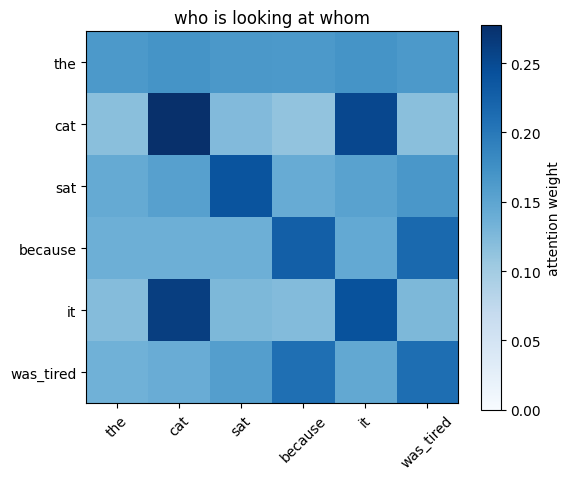

In [4]:
plt.figure(figsize=(6,5))
plt.imshow(weights, cmap='Blues', vmin=0)
plt.xticks(range(6), words, rotation=45)
plt.yticks(range(6), words)
plt.colorbar(label='attention weight')
plt.title('who is looking at whom')
plt.show()

In [5]:
row = weights[words.index('it')]
order = np.argsort(-row)
print("'it' attends most to :")
for i in order[:3]:
    print("  ", words[i].ljust(10), round(row[i], 3))

'it' attends most to :
   cat        0.262
   it         0.242
   was_tired  0.127


`it` puts its highest weight on `cat` (0.262), even ahead of itself (0.242). thats the coreference an english reader makes too, and it happened only because i gave the two words similar vectors, they share the animal and subject directions. no training happened, this is pure geometry of the vectors i wrote by hand.

## causal masking

for generating text a position must not see the future. the mask is a lower triangle, and blocked scores are set to a huge negative number so that softmax gives them zero.

In [6]:
T = len(words)
causal = np.tril(np.ones((T, T), dtype=bool))
print(causal.astype(int))

[[1 0 0 0 0 0]
 [1 1 0 0 0 0]
 [1 1 1 0 0 0]
 [1 1 1 1 0 0]
 [1 1 1 1 1 0]
 [1 1 1 1 1 1]]


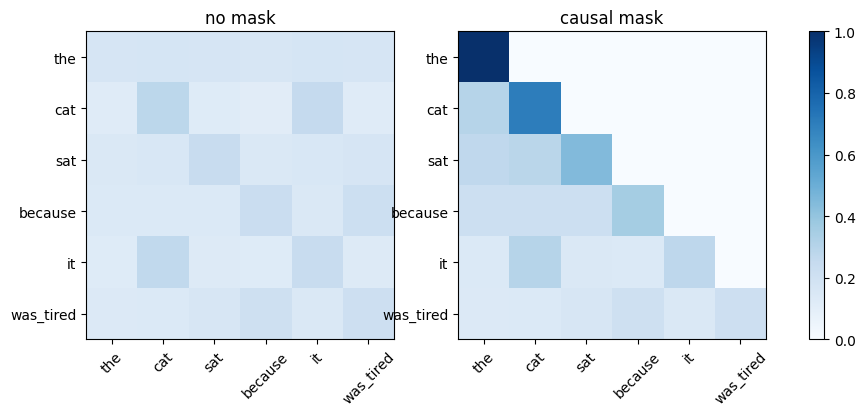

row for 'sat' with mask : [0.27 0.29 0.44 0.   0.   0.  ]  (everything after position 2 is zero)


In [7]:
out_m, weights_m = attention(Q, K, V, mask=causal)

fig, ax = plt.subplots(1, 2, figsize=(11,4))
for a, w, title in zip(ax, [weights, weights_m], ['no mask', 'causal mask']):
    im = a.imshow(w, cmap='Blues', vmin=0, vmax=1)
    a.set_xticks(range(T)); a.set_xticklabels(words, rotation=45)
    a.set_yticks(range(T)); a.set_yticklabels(words)
    a.set_title(title)
plt.colorbar(im, ax=ax)
plt.show()

print("row for 'sat' with mask :", np.round(weights_m[2], 2), " (everything after position 2 is zero)")

## multiple heads

one attention does one kind of comparison. multi head splits the vector into pieces and runs a seperate attention on each piece, so one head can track the subject while another tracks the action. then the outputs are concatenated back.

In [13]:
def multi_head(X, n_heads, seed=0):
    rng = np.random.default_rng(seed)
    d = X.shape[1]
    d_head = d // n_heads

    outs, all_weights = [], []
    for hd in range(n_heads):
        Wq = rng.normal(0, 0.8, (d, d_head))
        Wk = rng.normal(0, 0.8, (d, d_head))
        Wv = rng.normal(0, 0.8, (d, d_head))
        o, w = attention(X @ Wq, X @ Wk, X @ Wv)
        outs.append(o)
        all_weights.append(w)

    return np.concatenate(outs, axis=1), all_weights

out_mh, head_weights = multi_head(X, n_heads=2)
print("output shape :", out_mh.shape, " same width as the input, just built from 2 heads")

output shape : (6, 4)  same width as the input, just built from 2 heads


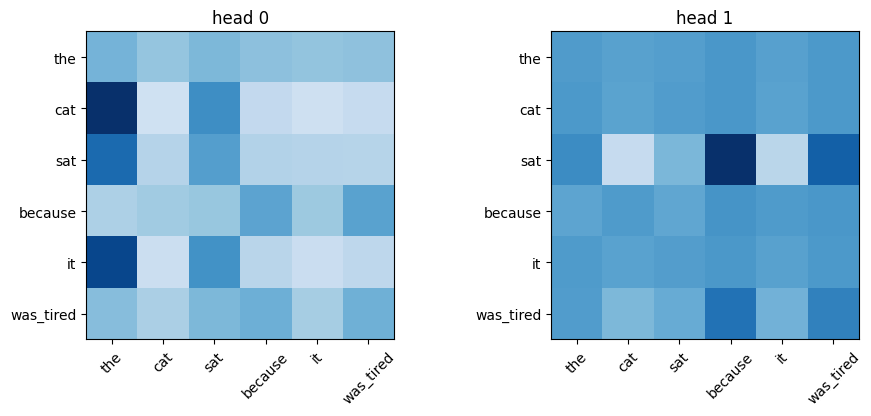

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11,4))
for j, w in enumerate(head_weights):
    ax[j].imshow(w, cmap='Blues', vmin=0)
    ax[j].set_xticks(range(T)); ax[j].set_xticklabels(words, rotation=45)
    ax[j].set_yticks(range(T)); ax[j].set_yticklabels(words)
    ax[j].set_title('head ' + str(j))
plt.show()

the two heads have random weights here so they are not meaningful, but the point is visible, they produce completly diffrent attention patterns from the same input. after training each head specialises.

## the cost

every position scores every other position, so the attention matrix is T x T.

In [11]:
for T_ in [10, 100, 1000, 10000]:
    print("sequence", str(T_).rjust(5), " attention matrix has", format(T_*T_, ','), "entries")

sequence    10  attention matrix has 100 entries
sequence   100  attention matrix has 10,000 entries
sequence  1000  attention matrix has 1,000,000 entries
sequence 10000  attention matrix has 100,000,000 entries


this is the reason long context is expensive. doubling the sequence makes attention four times bigger, wich is why context windows were small for years.

### what i learned

- the whole thing is 4 lines, `scores = QK^T/sqrt(d)`, mask, softmax, `@ V`
- masking is done by setting scores to a big negative number **before** the softmax, not by zeroing weights after
- with hand written vectors `it` really did attend to `cat`, no training needed, its just dot products
- multi head is not more layers, its the same width split into pieces
- cost is T squared, thats the real limitation